Using R installation at: C:\Program Files\R\R-4.4.1
Loading results from G:\My Drive\Experiments\NonparaFrechet\results\simulations\simulation_results.csv
Saved combined plot to G:\My Drive\Experiments\NonparaFrechet\results\simulations\boxplot_combined.pdf


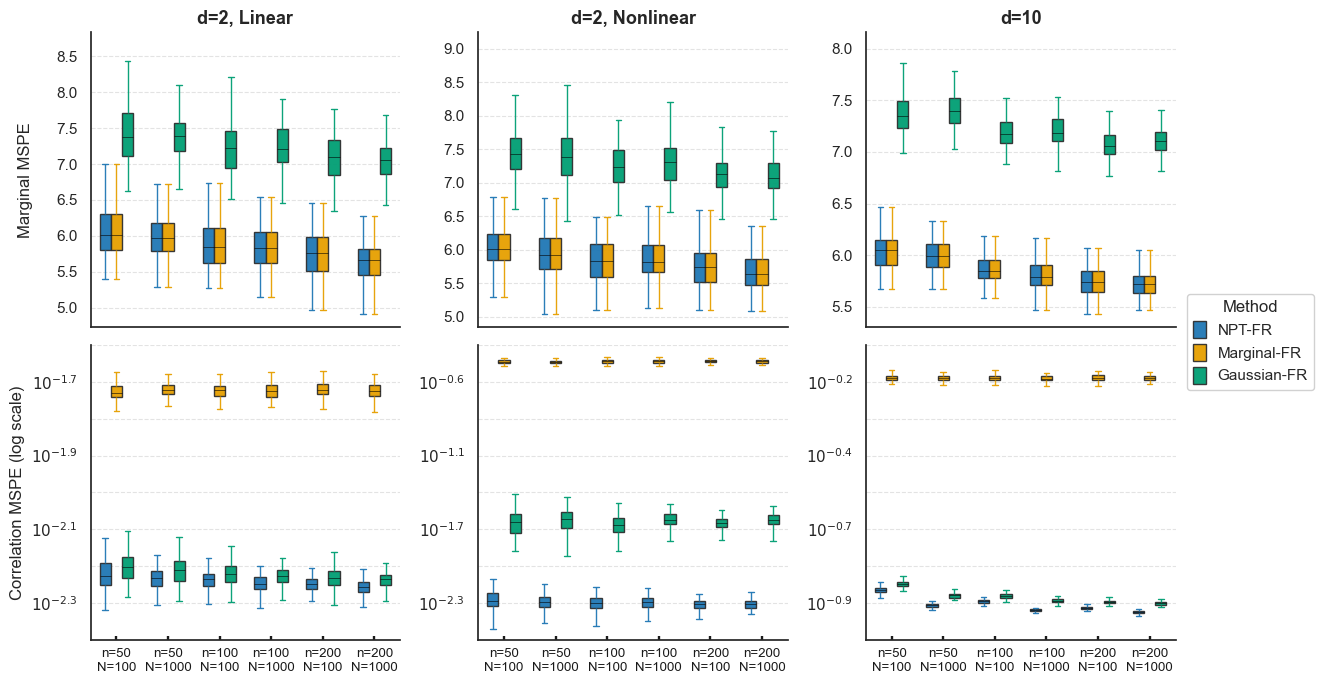

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "functions").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "functions").exists() and (parent / "experiments" / "simulation").exists():
            REPO_ROOT = parent
            break
SIM_DIR = REPO_ROOT / "experiments" / "simulation"
if str(SIM_DIR) not in sys.path:
    sys.path.insert(0, str(SIM_DIR))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Simulation import *

# df = run_simulations(reps=100, n_jobs=-1)
    
# Load existing results
csv_path = REPO_ROOT / 'results' / 'simulations' / 'simulation_results.csv'
if os.path.exists(csv_path):
    print(f"Loading results from {csv_path}")
    df = pd.read_csv(csv_path)
    plot_results(df, x_label_fontsize=9.5, x_label_rotation=0, palette = ["#1F77B4", "#E69F00", "#009E73"])

## Correlation visualization

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from simul_generation import joint_signal_generation
from gaussian_frechet import gaussian_frechetreg
from functions.regression import npt_frechetreg

# Configuration
d = 2
N = 1000
n = 200
SEED = 20251225
M = 200
quantile_grid = np.linspace(0, 1, M + 2)[1:-1]
rep = 1

types = ['linear', 'nonlinear']

Generating data for type: linear...
Running NPT Frechet Regression for linear...
Running Gaussian Frechet Regression for linear...
Generating data for type: nonlinear...
Running NPT Frechet Regression for nonlinear...
Running Gaussian Frechet Regression for nonlinear...
Plot saved to G:\My Drive\Experiments\NonparaFrechet\results\simulations\correlation_visualization_total.pdf


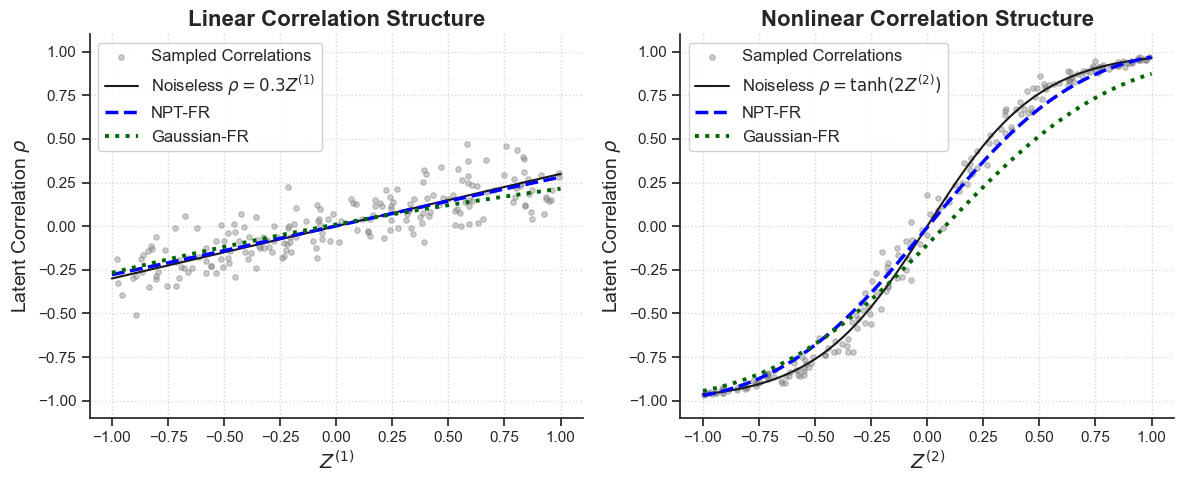

In [3]:
# Setup plot
sns.set_theme(style="ticks") # Cleaner style without heavy grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, type_name in enumerate(types):
    print(f"Generating data for type: {type_name}...")
    # Generate data
    # joint_signal_generation returns data (n, N, d) and joint_distribution
    data, joint_dist = joint_signal_generation(n=n, d=d, N=N, type=type_name, random_state=SEED)
    
    Z = joint_dist['Predictor'] # (n, 2)
    rhos = joint_dist['Latent_Corrs'][:, 0, 1] # True latent correlations (n,)
    
    ax = axes[i]
    
    # Add light grid
    ax.grid(True, linestyle=':', alpha=0.3, color='gray')
    
    if type_name == 'linear':
        # Plot against Z1
        x_vals = Z[:, 0]
        y_vals = rhos
        
        # Base graph: rho = 0.3 * Z1
        z_grid = np.linspace(-1, 1, 100)
        base_rho = 0.3 * z_grid
        
        ax.scatter(x_vals, y_vals, alpha=0.4, s=15, color='gray', label='Sampled Correlations')
        ax.plot(z_grid, base_rho, color='k', linewidth=1.5, label=r'Noiseless $\rho=0.3Z^{{(1)}}$')
        ax.set_xlabel(r'$Z^{{(1)}}$', fontsize=14)
        ax.set_title('Linear Correlation Structure', fontsize=16, fontweight='bold')
        
    elif type_name == 'nonlinear':
        # Plot against Z2
        x_vals = Z[:, 1]
        y_vals = rhos
        
        # Base graph: rho = tanh(2 * Z2)
        z_grid = np.linspace(-1, 1, 100)
        base_rho = np.tanh(2 * z_grid)
        
        ax.scatter(x_vals, y_vals, alpha=0.4, s=15, color='gray', label='Sampled Correlations')
        ax.plot(z_grid, base_rho, color='k', linewidth=1.5, label=r'Noiseless $\rho=\tanh(2Z^{{(2)}})$')
        ax.set_xlabel(r'$Z^{{(2)}}$', fontsize=14)
        ax.set_title('Nonlinear Correlation Structure', fontsize=16, fontweight='bold')
        
    # NPT Frechet Regression
    print(f"Running NPT Frechet Regression for {type_name}...")
    
    # Create prediction grid
    n_grid = 100
    z_grid_vals = np.linspace(-1, 1, n_grid)
    Z_pred = np.zeros((n_grid, 2))
    
    if type_name == 'linear':
        Z_pred[:, 0] = z_grid_vals
        # Z2 is irrelevant for linear case in truth, but we set to 0
    else:
        Z_pred[:, 1] = z_grid_vals
        # Z1 is irrelevant for nonlinear case in truth
        
    # Quantile grid for regression
    M = 200
    quantile_grid = np.linspace(0, 1, M + 2)[1:-1]
    
    res = npt_frechetreg(
        X=Z,
        Y=data,
        Z=Z_pred,
        M=quantile_grid,
        verbose=False,
        do_mse=False,
        do_cor_err=False
    )
    
    fitted_corrs = res['LatentCor'] # (n_grid, d, d)
    fitted_rhos = fitted_corrs[:, 0, 1]
    
    ax.plot(z_grid_vals, fitted_rhos, color='blue', linewidth=2.5, linestyle='--', label='NPT-FR')


    # Gaussian Frechet Regression
    print(f"Running Gaussian Frechet Regression for {type_name}...")
    result_gaussian = gaussian_frechetreg(
        X=Z,
        Y=data,
        Z=Z_pred,
        verbose=False
    )

    fitted_covs_gauss = result_gaussian['covs']
    gauss_corrs = np.zeros(fitted_covs_gauss.shape[0])

    for i in range(fitted_covs_gauss.shape[0]):
        cov_mat = fitted_covs_gauss[i]
        std_devs = np.sqrt(np.diag(cov_mat))
        corr_mat = cov_mat / np.outer(std_devs, std_devs)
        gauss_corrs[i] = corr_mat[0, 1]

    ax.plot(z_grid_vals, gauss_corrs, color='darkgreen', linewidth=2.8, linestyle=':', label='Gaussian-FR')

    ax.set_ylabel(r'Latent Correlation $\rho$', fontsize=14)
    ax.legend(fontsize=12, loc='upper left', frameon=True, framealpha=0.9)
    ax.set_ylim(-1.1, 1.1)
    
    # Remove top and right spines
    sns.despine()

plt.tight_layout()
output_dir = REPO_ROOT / 'results' / 'simulations'
# os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'correlation_visualization_total.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=500)
print(f"Plot saved to {output_path}")

## Wasserstein prediction error (supplementary)

In [3]:
# Load existing results
csv_path = REPO_ROOT / 'results' / 'simulations' / 'simulation_results_wasserstein'
files = ['_n50.csv', '_n100.csv', '_n200.csv']

df_list = []
for file in files:
    df_temp = pd.read_csv(csv_path + file)
    df_list.append(df_temp)
df = pd.concat(df_list, ignore_index=True)

In [2]:
def plot_results(
    df,
    *,
    out_path=None,
    figsize=None,
    hue_order=('NPT-FR', 'Marginal-FR', 'Gaussian-FR'),
    palette=None,
    showfliers=False,
    box_width=0.65,
    linewidth=1.0,
    unify_whisker_cap_style=True,
    grid_alpha=0.55,
    x_label_rotation=0,
    x_label_fontsize=10,
):

    # Create a combined column for (n, N)
    df = df.copy()
    df['n_N'] = df.apply(lambda x: f"n={x['n']}\nN={x['N']}", axis=1)
    
    # Sort to ensure correct plotting order (n major, N minor)
    df = df.sort_values(['n', 'N'])
    
    # Define settings (Columns)
    settings = [
        {'name': 'd=2, Linear', 'query': 'd == 2 and type == "linear"'},
        {'name': 'd=2, Nonlinear', 'query': 'd == 2 and type == "nonlinear"'},
        {'name': 'd=10', 'query': 'd == 10'}
    ]
    
    # Define metrics (Rows)
    metrics = ['Wasserstein']

    def _apply_common_aesthetics(ax):
        """Shared styling for all subplots."""
        ax.set_xlabel("")
        # Only horizontal grid lines, dashed and light.
        ax.grid(False)
        ax.yaxis.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=grid_alpha)
        ax.xaxis.grid(False)
        # Keep spines subtle
        for side in ['top', 'right']:
            ax.spines[side].set_visible(False)

    def _unify_box_whisker_cap_colors(ax):
        """Post-process seaborn/matplotlib artists so whiskers/caps match box color.

        Works across seaborn versions by pairing each box patch with its related
        Line2D objects in the order matplotlib generates them.
        """
        import matplotlib.patches as mpatches

        # Collect boxes in draw order
        boxes = [p for p in ax.patches if isinstance(p, mpatches.PathPatch)]
        if not boxes:
            return

        # Matplotlib's bxp typically adds per box:
        # - 2 whiskers + 2 caps + 1 median (+ fliers if enabled)
        lines = list(ax.lines)

        # Heuristic: per box, recolor the next 4 Line2D objects whose x-data has
        # The first 4 lines in each group correspond to whiskers/caps.
        per_box = 5 if not showfliers else 6
        for bi, box in enumerate(boxes):
            color = box.get_facecolor()
            start = bi * per_box
            group = lines[start:start + per_box]
            if not group:
                continue

            # whisker(2) + cap(2) are usually first 4
            for ln in group[:4]:
                ln.set_color(color)
            # median is usually 5th (keep it black for readability)
            if len(group) >= 5:
                group[4].set_color('black')
                # Keep median thickness controlled by medianprops.
    
    # Setup plot
    sns.set_theme(style="white")
    # Transposed layout: Rows=Metrics, Cols=Settings
    # Removed sharey='row' to allow independent y-limits for each panel
    if figsize is None:
        figsize = (4.5 * len(settings), 3.5 * len(metrics))

    fig, axes = plt.subplots(nrows=len(metrics), ncols=len(settings), 
                             figsize=figsize, 
                             sharex='col', squeeze=False)
    
    # Palette: by default use matplotlib's active color cycle. Allow override.
    if palette is None:
        palette = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)[:len(hue_order)]

    # Pre-compute global y-limits for Marginal (row 1) per setting (column)
    # so that within each column, methods share the same y-scale.
    marginal_ylim_by_setting = {}
    for setting in settings:
        subset_setting = df.query(setting['query'])
        sub = subset_setting[subset_setting['metric'] == 'Marginal']['value']
        sub = np.asarray(np.ma.masked_invalid(sub).compressed())
        if sub.size == 0:
            continue
        ymin = sub.min()
        ymax = sub.max()
        # Add a tiny additive pad for linear scale readability
        pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.05 * max(1.0, abs(ymax))
        marginal_ylim_by_setting[setting['name']] = (ymin - pad, ymax + pad)

    for j, setting in enumerate(settings):
        subset_setting = df.query(setting['query'])
        
        if subset_setting.empty:
            print(f"No data for setting: {setting['name']}")
            continue
            
        for i, metric in enumerate(metrics):
            ax = axes[i, j]
            metric_data = subset_setting[subset_setting['metric'] == metric].copy()
            
            if metric_data.empty:
                continue
            
            # Ensure sorting for this specific subset
            metric_data = metric_data.sort_values(['n', 'N'])

            sns.boxplot(
                data=metric_data,
                x='n_N',
                y='value',
                hue='method',
                hue_order=list(hue_order) if hue_order is not None else None,
                ax=ax,
                showfliers=showfliers,
                width=box_width,
                linewidth=linewidth,
                saturation=1.0,
                boxprops={'alpha': 0.95, 'linewidth': linewidth},
                whiskerprops={'linewidth': linewidth},
                capprops={'linewidth': linewidth},
                medianprops={'linewidth': linewidth-0.6, 'color': 'black'},
                palette=palette
            )

            _apply_common_aesthetics(ax)
            
            # Titles (only on top row) - Bold font
            if i == 0:
                ax.set_title(setting['name'], fontweight='bold', fontsize=13)
            
            # Y Labels (only on first column)
            if j == 0:
                ax.set_ylabel(f"{metric} MSPE\n", fontsize=12) # Averages across marginals could be reflected
            else:
                ax.set_ylabel("")

            # X tick labels adjustments (rotation) for readability (apply to bottom row)
            if i == len(metrics) - 1:
                ax.tick_params(axis='x', labelsize=x_label_fontsize, pad=6, bottom=True, length=3, width=1.7, colors='0.1', direction='in')
                for tick in ax.get_xticklabels():
                    tick.set_rotation(x_label_rotation)

            # If requested: make whiskers/caps same width+color as their box.
            if unify_whisker_cap_style:
                _unify_box_whisker_cap_colors(ax)
                
            # Remove legend from individual plots
            if ax.get_legend():
                ax.get_legend().remove()

    # Global Legend
    # Get handles and labels from the first plot (assuming it contains all methods)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.985, 0.5), title='Method', fontsize=11, title_fontsize=12,  handlelength=0.8, handleheight=1.3, # box size inside the legend
               labelspacing=0.4, frameon=True, framealpha=0.9)
    
    # Adjust layout to make room for legend on the right
    plt.tight_layout(rect=(0, 0, 0.89, 1))
    
    # Save
    if out_path is None:
        output_dir = REPO_ROOT / 'results' / 'simulations'
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, 'boxplot_Wasserstein.png')
    else:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)

    plt.savefig(out_path, bbox_inches='tight', dpi=500)
    print(f"Saved combined plot to {out_path}")

Saved combined plot to g:\My Drive\Experiments\Multivar-Wasserstein\experiments\..\results\simulations\boxplot_Wasserstein.png


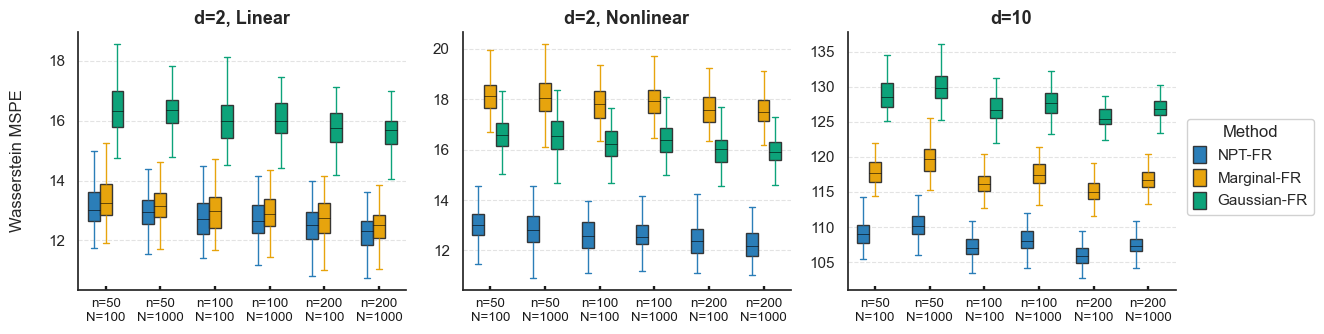

In [4]:
plot_results(df, x_label_fontsize=9.5, x_label_rotation=0, palette = ["#1F77B4", "#E69F00", "#009E73"])

## Heatmap for the nonlinear setting (auxiliary)

NPT vs. Gaussian fits to compare the ability to capture skewness

Uses first run of the simulation.

In [4]:
from experiments.simulation.simul_wasserstein_eval import sample_from_npt, sample_from_gaussian

In [ ]:
type_name = 'nonlinear'
n_te = 500

seed_val = (SEED + rep + n + d * 1000 + hash(type_name) % (100000))
RS = np.random.RandomState(seed_val)

# Create a separate RNG for test data to ensure consistency across N
test_seed = (seed_val + 123456789) % (2**32 - 1)
RS_test = np.random.RandomState(test_seed)

# Generate train data
data, joint_distribution = joint_signal_generation(n=n, d=d, N=N, type=type_name, random_state=RS)

# Evaluation points
num_plots = 5
first_col = np.zeros(num_plots)
# second_col = np.linspace(-0.5, 0.5, num_plots)
second_col = np.linspace(-1.0, 1.0, num_plots + 2)[1:-1]
Z = np.column_stack([first_col, second_col])

# 1) NPT Frechet Regression (NPT)
result_npt = npt_frechetreg(
    X=joint_distribution['Predictor'],
    Y=data,
    Z=Z,
    M=quantile_grid,
    verbose=False,
    do_mse=False,
    do_cor_err=False
 )

npt_marginals = result_npt['Marginals']  # list of length d, each (n_test, M)
npt_corrs = result_npt['LatentCor']      # (n_test, d, d)

# 2) Gaussian Frechet Regression
result_gaussian = gaussian_frechetreg(
    joint_distribution['Predictor'],
    data,
    Z=Z,
    verbose=False
 )
gauss_means = result_gaussian['means']
gauss_covs = result_gaussian['covs']

# Collect samples first (keeps plotting clean and lets us standardize limits/vmax).
n_samples = 2000
X_npt_list = []
X_gauss_list = []
for i in range(num_plots):
    curr_npt_marginals = np.array([npt_marginals[j][i] for j in range(d)])
    # Python indexing issue fix: multiply by -1 to flip signs
    X_npt_i = -1 * sample_from_npt(
        n_samples, curr_npt_marginals, npt_corrs[i], quantile_grid, random_state=RS
    )
    X_gauss_i = -1 * sample_from_gaussian(
        n_samples, gauss_means[i], gauss_covs[i], random_state=RS
    )
    X_npt_list.append(X_npt_i)
    X_gauss_list.append(X_gauss_i)

C:\Users\Junyoung\AppData\Local\Temp\ipykernel_43204\1243469302.py:139: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(REPO_ROOT / 'results' / 'simulations' / 'd2_heatmaps.png', dpi=500, bbox_inches='tight')
c:\Users\Junyoung\anaconda3\envs\TF\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Junyoung\anaconda3\envs\TF\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


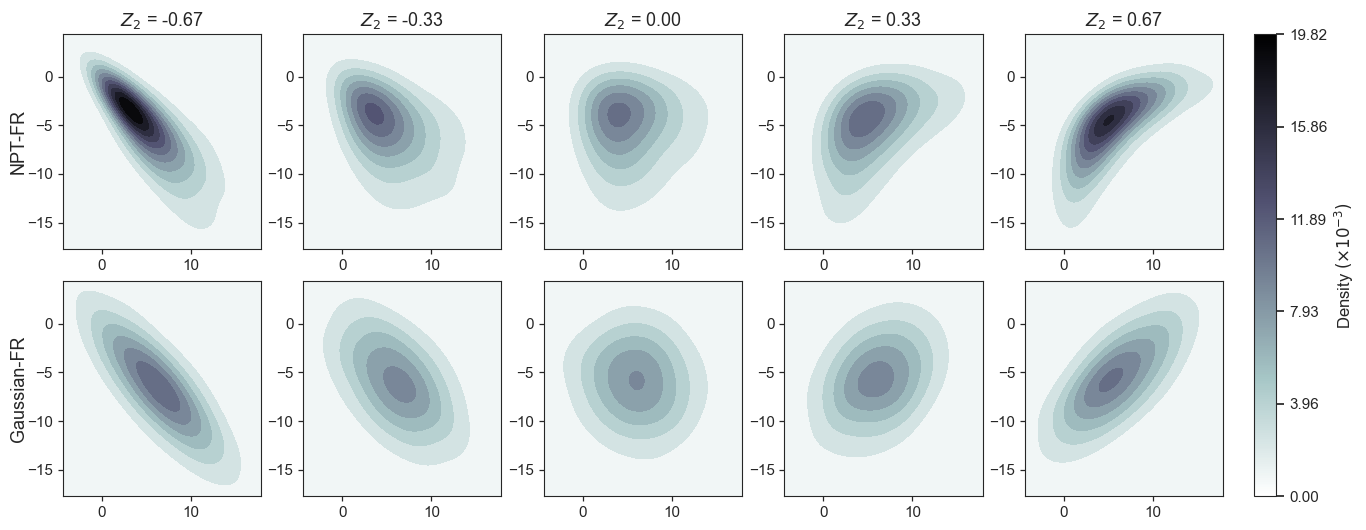

In [ ]:
# -----------------------------
# 2 x num_plots empirical heatmaps (contourf)
# Top row: NPT-FR samples, Bottom row: Gaussian-FR samples
# Style aligned with `plot_multivar_distributions` defaults (bone_r colormap).
# -----------------------------
from scipy.stats import gaussian_kde
from matplotlib import gridspec
import matplotlib as mpl

grid_res = 140  # density grid resolution
n_levels = 13   # keep same as plot_helper for contours
cmap = 'bone_r'

# Slightly smoother KDE than default (Scott)
bw_scale = 1.7  # >1 => smoother
def bw_method(kde_obj):
    return kde_obj.scotts_factor() * bw_scale

# Shared axis limits across all 10 panels
all_X = np.vstack(X_npt_list + X_gauss_list)  # (10*n_samples, 2)
x_min, x_max = np.quantile(all_X[:, 0], [0.003, 0.991])
y_min, y_max = np.quantile(all_X[:, 1], [0.009, 0.997])

# Shared density scale (compute KDE on each panel, then pick one vmax)
x_grid = np.linspace(x_min, x_max, grid_res)
y_grid = np.linspace(y_min, y_max, grid_res)
xx, yy = np.meshgrid(x_grid, y_grid)
positions = np.vstack([xx.ravel(), yy.ravel()])

def _kde_on_grid(X):
    values = np.vstack([X[:, 0], X[:, 1]])
    kde = gaussian_kde(values, bw_method=bw_method)
    zz = np.reshape(kde(positions).T, xx.shape) * 1e3  # match plot_helper scaling
    return zz

zz_npt = []
zz_gauss = []
for i in range(num_plots):
    zz_npt.append(_kde_on_grid(X_npt_list[i]))
    zz_gauss.append(_kde_on_grid(X_gauss_list[i]))

vmin = 0.0
vmax = max([float(np.max(z)) for z in (zz_npt + zz_gauss)])
levels = np.linspace(vmin, vmax, n_levels)

# Plot grid + single colorbar (no overlap)
sns.set_theme(style="ticks")
fig = plt.figure(
    figsize=(2.9 * num_plots + 1.3, 6.0),
    constrained_layout=True,  # helps prevent tick-label bleed + avoids tight_layout warnings
 )
gs = gridspec.GridSpec(
    2, num_plots + 1,
    width_ratios=[1] * num_plots + [0.11],  # thicker colorbar
    wspace=0.25, hspace=0.15,  # a bit of breathing room for tick labels
 )

axes = np.empty((2, num_plots), dtype=object)
for r in range(2):
    for c in range(num_plots):
        axes[r, c] = fig.add_subplot(gs[r, c])

cax = fig.add_subplot(gs[:, -1])

# Nudge the colorbar axis a tiny bit left (fraction of figure coords)
# Increase `cax_left_shift` slightly if you want more movement.
cax_left_shift = 0.007
pos = cax.get_position()
cax.set_position([pos.x0 - cax_left_shift, pos.y0, pos.width, pos.height])

# Spine styling: thin but fully boxed (top/right included)
spine_lw = 0.8
for r in range(2):
    for c in range(num_plots):
        ax = axes[r, c]
        for side in ['left', 'bottom', 'right', 'top']:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(spine_lw)

mappable = None
for col in range(num_plots):
    # Top row: NPT-FR
    ax_top = axes[0, col]
    z_top = np.clip(zz_npt[col], vmin, vmax)
    mappable = ax_top.contourf(xx, yy, z_top, cmap=cmap, levels=levels, vmin=vmin, vmax=vmax)
    ax_top.set_title(rf'$Z_2$ = {Z[col, 1]:.2f}', fontsize=13)
    ax_top.set_xlim(x_min, x_max)
    ax_top.set_ylim(y_min, y_max)

    # Bottom row: Gaussian-FR
    ax_bot = axes[1, col]
    z_bot = np.clip(zz_gauss[col], vmin, vmax)
    ax_bot.contourf(xx, yy, z_bot, cmap=cmap, levels=levels, vmin=vmin, vmax=vmax)
    ax_bot.set_xlim(x_min, x_max)
    ax_bot.set_ylim(y_min, y_max)

# Remove axis labels everywhere (keep only outer ticks if desired)
for r in range(2):
    for c in range(num_plots):
        axes[r, c].set_xlabel('')
        axes[r, c].set_ylabel('')

# Remove interior ticks (no tick marks/labels for middle panels)
for r in range(2):
    for c in range(num_plots):
        ax = axes[r, c]
        # x tick labels only on bottom row
        # if r == 0:
        #     # ax.set_xticks([])
        #     ax.tick_params(axis='x', labelbottom=False)
        # # y tick labels only on first column
        # if c != 0:
        #     # ax.set_yticks([])
        #     ax.tick_params(axis='y', labelleft=False)
        ax.tick_params(length=3.5, width=0.9)

# Row labels
axes[0, 0].text(
    -0.22, 0.5, 'NPT-FR', transform=axes[0, 0].transAxes, rotation=90,
    va='center', ha='center', fontsize=13
 )
axes[1, 0].text(
    -0.22, 0.5, 'Gaussian-FR', transform=axes[1, 0].transAxes, rotation=90,
    va='center', ha='center', fontsize=13
 )

# Continuous-looking colorbar without changing contour levels: use ScalarMappable + Normalize
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'Density $(\times 10^{-3})$')
cbar.outline.set_linewidth(spine_lw)

# ~6 ticks across full range
tick_vals = np.linspace(vmin, vmax, 6)
cbar.set_ticks(tick_vals)

plt.savefig(REPO_ROOT / 'results' / 'simulations' / 'd2_heatmaps.png', dpi=500, bbox_inches='tight')
plt.show()